# **Stock Price Prediction**



### Install yfinance library

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd

# Select a stock ticker (e.g., Apple, 'AAPL') and a date range
ticker = 'AAPL'
start_date = '2018-01-01'
end_date = '2023-01-01'

# Download historical data
df = yf.download(ticker, start=start_date, end=end_date)

print(f"Successfully downloaded data for {ticker} from {start_date} to {end_date}.")

# Display the first 5 rows and information about the DataFrame
display(df.head())
print("\nDataFrame Info:")
df.info()

/tmp/ipykernel_2971/988393851.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Successfully downloaded data for AAPL from 2018-01-01 to 2023-01-01.


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.267075,40.276427,39.565802,39.776186,102223600
2018-01-03,40.260052,40.802371,40.196940,40.330180,118071600
2018-01-04,40.447067,40.549921,40.224998,40.332525,89738400
2018-01-05,40.907570,40.994059,40.451743,40.542909,94640000
2018-01-08,40.755627,41.050160,40.657445,40.755627,82271200



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1259 entries, 2018-01-02 to 2022-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1259 non-null   float64
 1   (High, AAPL)    1259 non-null   float64
 2   (Low, AAPL)     1259 non-null   float64
 3   (Open, AAPL)    1259 non-null   float64
 4   (Volume, AAPL)  1259 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [ ]:
import kagglehub
import pandas as pd
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("suruchiarora/yahoo-finance-dataset-2018-2023")

print("Path to dataset files:", path)

100%|██████████| 77.5k/77.5k [00:00<00:00, 17.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/suruchiarora/yahoo-finance-dataset-2018-2023/versions/1


In [ ]:
# Assuming the dataset contains an Excel file, we'll try to find and load it.
# List files in the downloaded path
files = os.listdir(path)
excel_file = None
for f in files:
    if f.endswith('.xlsx'):
        excel_file = os.path.join(path, f)
        break

if excel_file:
    df = pd.read_excel(excel_file)
    print(f"Loaded data from: {excel_file}")
    display(df.head())
else:
    print("No Excel file found in the downloaded dataset path.")

Loaded data from: /root/.cache/kagglehub/datasets/suruchiarora/yahoo-finance-dataset-2018-2023/versions/1/yahoo_data.xlsx


,Date,Open,High,Low,Close*,Adj Close**,Volume
0,"Apr 28, 2023",33797.43,34104.56,33728.40,34098.16,34098.16,354310000
1,"Apr 27, 2023",33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2,"Apr 26, 2023",33596.34,33645.83,33235.85,33301.87,33301.87,321170000
3,"Apr 25, 2023",33828.34,33875.49,33525.39,33530.83,33530.83,297880000
4,"Apr 24, 2023",33805.04,33891.15,33726.09,33875.40,33875.40,252020000


## Data Preprocessing and Exploration

In [ ]:
# Flatten multi-level columns if they exist (common with yfinance)
if isinstance(df.columns, pd.MultiIndex):
    # yfinance often returns ('ColumnName', 'Ticker'), so droplevel(1) removes the ticker
    df.columns = df.columns.droplevel(1)
    print("Multi-level columns flattened.")

# Ensure the index is a DatetimeIndex and sorted (yfinance usually does this but good to check)
if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)
    print("Index converted to DatetimeIndex and sorted.")

print("DataFrame head after initial preprocessing:")
display(df.head())

# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

Multi-level columns flattened.
DataFrame head after initial preprocessing:


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.267075,40.276427,39.565802,39.776186,102223600
2018-01-03,40.260052,40.802371,40.196940,40.330180,118071600
2018-01-04,40.447067,40.549921,40.224998,40.332525,89738400
2018-01-05,40.907570,40.994059,40.451743,40.542909,94640000
2018-01-08,40.755627,41.050160,40.657445,40.755627,82271200



Missing values per column:


,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0


## Feature Engineering and Target Variable Creation

In [ ]:
# Create the target variable (next day's Close price)
# Note: yfinance data typically has 'Close' column directly after flattening
df['target_Close'] = df['Close'].shift(-1)

# Define features (X) and target (y)
features = ['Open', 'High', 'Low', 'Volume', 'Close']
X = df[features]
y = df['target_Close']

# Drop the last row which will have NaN for target_Close
X = X.iloc[:-1]
y = y.iloc[:-1]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nFirst 5 rows of features (X):")
display(X.head())
print("\nFirst 5 rows of target (y):")
display(y.head())

Features (X) shape: (1258, 5)
Target (y) shape: (1258,)

First 5 rows of features (X):


Price,Open,High,Low,Volume,Close
Date,,,,,
2018-01-02,39.776186,40.276427,39.565802,102223600,40.267075
2018-01-03,40.330180,40.802371,40.196940,118071600,40.260052
2018-01-04,40.332525,40.549921,40.224998,89738400,40.447067
2018-01-05,40.542909,40.994059,40.451743,94640000,40.907570
2018-01-08,40.755627,41.050160,40.657445,82271200,40.755627



First 5 rows of target (y):


,target_Close
Date,
2018-01-02,40.260052
2018-01-03,40.447067
2018-01-04,40.907570
2018-01-05,40.755627
2018-01-08,40.750957


## Model Training: Linear Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("\nLinear Regression model trained successfully.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

X_train shape: (1006, 5)
X_test shape: (252, 5)
y_train shape: (1006,)
y_test shape: (252,)

Linear Regression model trained successfully.

Mean Squared Error (MSE): 11.42
R-squared (R2): 0.93


## Visualization: Actual vs. Predicted Closing Prices

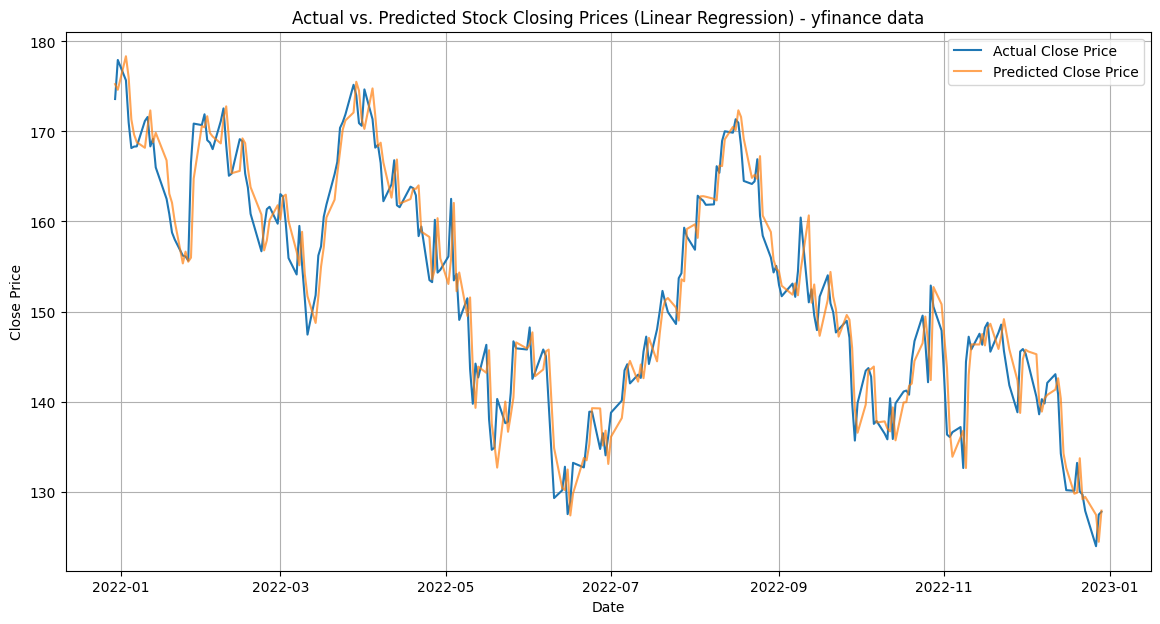

In [ ]:
import matplotlib.pyplot as plt

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
}, index=y_test.index)

# Plot the actual and predicted values
plt.figure(figsize=(14, 7))
plt.plot(plot_df['Actual'], label='Actual Close Price')
plt.plot(plot_df['Predicted'], label='Predicted Close Price', alpha=0.7)
plt.title('Actual vs. Predicted Stock Closing Prices (Linear Regression) - yfinance data')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

## Model Training: Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("\nRandom Forest Regressor model trained successfully.")

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest R-squared (R2): {r2_rf:.2f}")


Random Forest Regressor model trained successfully.

Random Forest Mean Squared Error (MSE): 16.27
Random Forest R-squared (R2): 0.90


## Visualization: Actual vs. Predicted Closing Prices (Random Forest)

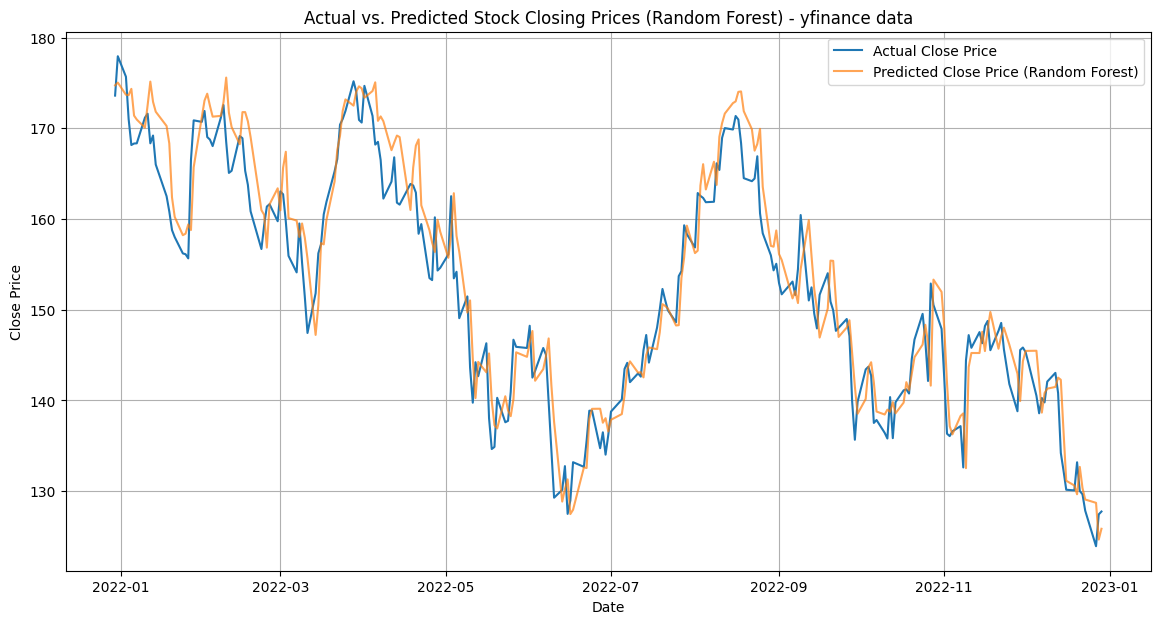

In [ ]:
# Create a DataFrame for plotting Random Forest predictions
plot_df_rf = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_rf
}, index=y_test.index)

# Plot the actual and predicted values for Random Forest
plt.figure(figsize=(14, 7))
plt.plot(plot_df_rf['Actual'], label='Actual Close Price')
plt.plot(plot_df_rf['Predicted'], label='Predicted Close Price (Random Forest)', alpha=0.7)
plt.title('Actual vs. Predicted Stock Closing Prices (Random Forest) - yfinance data')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()